# Eksplorasi Data Ulasan Produk Tokopedia

Tujuan notebook ini adalah mengenal data ulasan sebelum dipakai untuk membuat model sentimen. Belum ada pembersihan data di sini. Daftar masalah di akhir notebook menjadi rencana kerja untuk tahap data prep.

Dataset: `Dataset/raw/tokopedia-product-reviews-2019.csv`, berisi ulasan pembeli Tokopedia tahun 2019.

## 1. Muat data

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = pd.read_csv("../Dataset/raw/tokopedia-product-reviews-2019.csv")
df.head()

,Unnamed: 0,text,rating,category,product_name,product_id,sold,shop_id,product_url
0,1,Barang sesuai pesanan dan cepat sampai,5,pertukangan,Staples Dekorasi Staples Kayu + Refill 8mm - S...,418660637,1,1740837,https://www.tokopedia.com/shakaonline87/staple...
1,2,Barang bagus harga murah,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...
2,3,Paket rapi...mantap....cepat....sampe ke tujuan,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...
3,4,ya saya puas dgn barangnya,5,pertukangan,ALAT STAPLES TEMBAK &#40;AIR NAILER GUN&#41; O...,102279869,5,771395,https://www.tokopedia.com/kamarmesin/alat-stap...
4,5,Responya luar biasa b mantap,5,pertukangan,Isi Refill Staples Jok Kulit Motor / Staple Gu...,190679689,787,969999,https://www.tokopedia.com/mitrapersada/isi-ref...


In [2]:
# Gaya grafik, sama dengan notebook sebelumnya
BIRU = "#2a78d6"
BIRU_MUDA = "#9cc3ef"
ORANYE = "#eb6834"
ORANYE_MUDA = "#f5b394"
ABU = "#c8c6bf"
TEKS = "#52514e"

# Warna rating 1 sampai 5: oranye untuk rating rendah, abu-abu untuk 3, biru untuk rating tinggi
WARNA_RATING = {1: ORANYE, 2: ORANYE_MUDA, 3: ABU, 4: BIRU_MUDA, 5: BIRU}

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#8a8983",
    "axes.labelcolor": TEKS,
    "xtick.color": TEKS,
    "ytick.color": TEKS,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
})


def angka(x):
    return f"{x:,.0f}".replace(",", ".")

Catatan:

Data berisi 40.607 ulasan dengan 9 kolom. Kolom yang paling penting untuk model sentimen adalah `text` (isi ulasan) dan `rating` (bintang 1 sampai 5). Kolom `category` berisi lima kategori: elektronik, fashion, olahraga, handphone, dan pertukangan.

Kolom `Unnamed: 0` hanyalah nomor baris bawaan dari file aslinya dan tidak punya arti, jadi nanti dibuang.

## 2. Struktur data dan nilai kosong

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40607 entries, 0 to 40606
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Unnamed: 0    40607 non-null  int64
 1   text          40607 non-null  str  
 2   rating        40607 non-null  int64
 3   category      40607 non-null  str  
 4   product_name  40607 non-null  str  
 5   product_id    40607 non-null  int64
 6   sold          40593 non-null  str  
 7   shop_id       40607 non-null  int64
 8   product_url   40607 non-null  str  
dtypes: int64(4), str(5)
memory usage: 11.1 MB


In [4]:
df.isna().sum()

Unnamed: 0       0
text             0
rating           0
category         0
product_name     0
product_id       0
sold            14
shop_id          0
product_url      0
dtype: int64

Catatan:

Kolom `text` dan `rating` lengkap, tidak ada yang kosong. Satu-satunya kolom dengan nilai kosong adalah `sold` (14 baris), dan kolom itu tidak dipakai untuk model sentimen.

Kolom `sold` bertipe teks karena ada nilai seperti "2,9rb", sama seperti kolom `Terjual` di dataset produk. Kolom ini juga tidak dibutuhkan untuk tujuan notebook ini.

## 3. Sebaran rating

In [5]:
sebaran = df["rating"].value_counts().sort_index()
pd.DataFrame({"jumlah": sebaran, "persen": (sebaran / len(df) * 100).round(1)})

,jumlah,persen
rating,,
1,543,1.3
2,382,0.9
3,1825,4.5
4,7546,18.6
5,30311,74.6


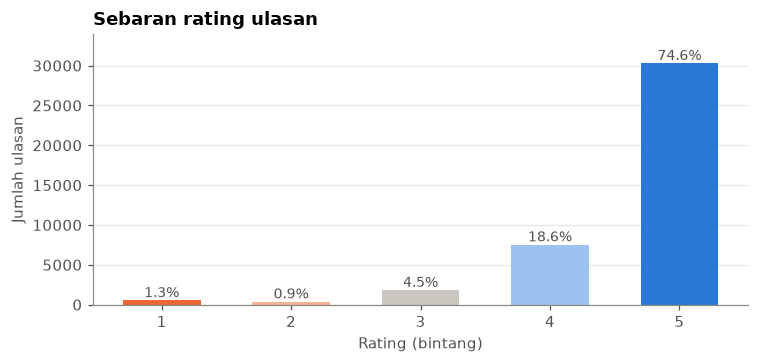

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(sebaran.index, sebaran.values, color=[WARNA_RATING[r] for r in sebaran.index], width=0.6)
for r, v in sebaran.items():
    ax.text(r, v + 400, f"{v / len(df):.1%}", ha="center", fontsize=9, color=TEKS)
ax.set_ylim(0, sebaran.max() * 1.12)
ax.set_title("Sebaran rating ulasan")
ax.set_xlabel("Rating (bintang)")
ax.set_ylabel("Jumlah ulasan")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

Catatan:

Rating sangat tidak seimbang. Sebanyak 74,6% ulasan memberi bintang 5 dan 18,6% bintang 4. Ulasan bintang 1 dan 2 digabung hanya 925 ulasan (2,3%).

Ketidakseimbangan ini adalah tantangan terbesar untuk model sentimen. Model yang selalu menebak "positif" untuk semua ulasan akan benar sekitar 93% dari waktu, padahal sama sekali tidak berguna, karena tidak pernah bisa mengenali ulasan negatif. Karena itu, di tahap model nanti akurasi saja tidak cukup untuk menilai model. Perlu ukuran lain yang melihat seberapa baik model mengenali ulasan negatif.

## 4. Rating per kategori

In [7]:
per_kategori = pd.crosstab(df["category"], df["rating"], normalize="index")
per_kategori = per_kategori.sort_values(5)
(per_kategori * 100).round(1)

rating,1,2,3,4,5
category,,,,,
handphone,4.3,2.6,8.0,21.1,64.0
olahraga,0.5,0.7,6.1,25.7,67.0
pertukangan,0.8,0.5,4.2,22.6,71.9
fashion,1.3,0.9,4.2,16.4,77.3
elektronik,0.7,0.5,2.5,14.9,81.4


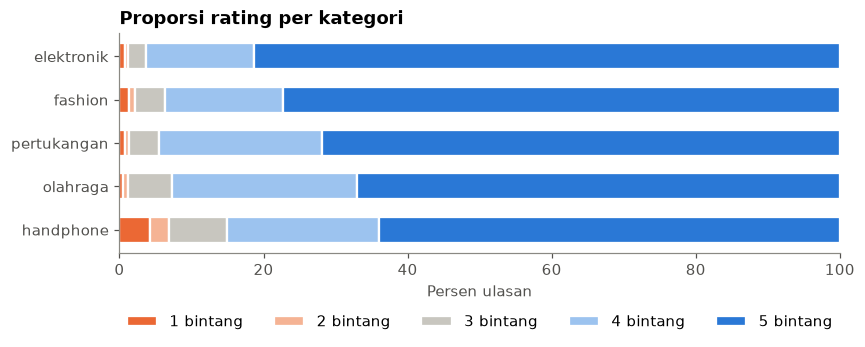

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.4))
kiri = np.zeros(len(per_kategori))
for r in per_kategori.columns:
    nilai = per_kategori[r].values * 100
    ax.barh(per_kategori.index, nilai, left=kiri, color=WARNA_RATING[r], height=0.6,
            edgecolor="white", linewidth=1.5, label=f"{r} bintang")
    kiri += nilai
ax.set_xlim(0, 100)
ax.set_title("Proporsi rating per kategori")
ax.set_xlabel("Persen ulasan")
ax.grid(False)
ax.legend(ncols=5, loc="upper center", bbox_to_anchor=(0.5, -0.22), frameon=False)
plt.tight_layout()
plt.show()

In [9]:
negatif = df[df["rating"] <= 2]
pd.DataFrame({
    "porsi_semua_ulasan": df["category"].value_counts(normalize=True),
    "porsi_ulasan_negatif": negatif["category"].value_counts(normalize=True),
}).round(3)

,porsi_semua_ulasan,porsi_ulasan_negatif
category,,
elektronik,0.391,0.203
fashion,0.219,0.209
handphone,0.151,0.459
olahraga,0.193,0.103
pertukangan,0.045,0.026


Catatan:

Handphone adalah kategori dengan ulasan negatif terbanyak. Sekitar 7% ulasannya bintang 1 atau 2, jauh di atas kategori lain yang semuanya di bawah 2,5%. Handphone hanya 15% dari seluruh ulasan, tetapi menyumbang 46% dari semua ulasan negatif.

Elektronik adalah kategori paling positif, dengan 81% ulasan bintang 5.

Ini juga berarti sebagian besar contoh ulasan negatif yang akan dipelajari model berasal dari kategori handphone. Model bisa jadi lebih mengenal keluhan tentang handphone daripada keluhan di kategori lain.

## 5. Panjang ulasan

In [10]:
df["jumlah_kata"] = df["text"].str.split().str.len()
df["jumlah_kata"].describe()

count    40607.000000
mean         7.940626
std          7.171776
min          1.000000
25%          4.000000
50%          6.000000
75%          9.000000
max        208.000000
Name: jumlah_kata, dtype: float64

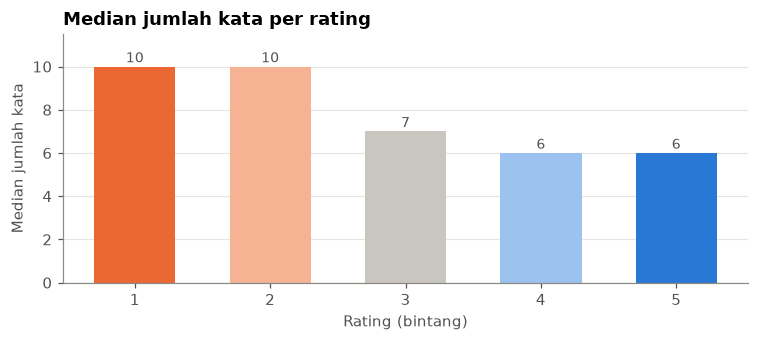

In [11]:
median_kata = df.groupby("rating")["jumlah_kata"].median()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(median_kata.index, median_kata.values, color=[WARNA_RATING[r] for r in median_kata.index], width=0.6)
for r, v in median_kata.items():
    ax.text(r, v + 0.2, angka(v), ha="center", fontsize=9, color=TEKS)
ax.set_ylim(0, median_kata.max() * 1.15)
ax.set_title("Median jumlah kata per rating")
ax.set_xlabel("Rating (bintang)")
ax.set_ylabel("Median jumlah kata")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

In [12]:
print("Ulasan 1 kata   :", angka((df["jumlah_kata"] == 1).sum()))
print("Ulasan <= 3 kata:", angka((df["jumlah_kata"] <= 3).sum()))
df.loc[df["jumlah_kata"] == 1, "text"].value_counts().head(10)

Ulasan 1 kata   : 1.824
Ulasan <= 3 kata: 5.653


text
Terimakasih...........................                           9
Siiiiiiiiiippppppppp                                             7
......................                                           6
..................................                               6
Toooooooooooooooooooooooooop                                     6
👍👍👍👍👍👍👍👍👍👍                                                       5
.....................                                            5
bagussssssssssssssss                                             5
.............................................................    5
Bagus...............                                             5
Name: count, dtype: int64

Catatan:

Ulasan umumnya pendek, dengan median 6 kata. Ulasan negatif cenderung lebih panjang (median 10 kata untuk bintang 1 dan 2) dibanding ulasan positif (6 kata). Masuk akal, karena pembeli yang kecewa biasanya menjelaskan masalahnya, sedangkan pembeli yang puas cukup menulis "barang sesuai pesanan".

Ada 1.824 ulasan yang hanya terdiri dari satu "kata". Banyak di antaranya bukan kata biasa, misalnya "Siiiiiiiiiippppppppp", deretan titik, atau deretan emoji. Setelah tanda baca dan emoji dibuang saat data prep, sebagian ulasan ini akan menjadi kosong dan perlu dibuang.

## 6. Duplikat

In [13]:
print("Baris yang persis sama (tanpa kolom nomor):", df.drop(columns="Unnamed: 0").duplicated().sum())
print("Teks ulasan yang sama                     :", df.duplicated("text").sum())
print("Teks sama pada produk yang sama           :", df.duplicated(["text", "product_id"]).sum())

Baris yang persis sama (tanpa kolom nomor): 0
Teks ulasan yang sama                     : 3306
Teks sama pada produk yang sama           : 17


In [14]:
df["text"].value_counts().head(10)

text
Barang sesuai deskripsi                   57
pemesanan diproses secepat kilat          38
Barang sesuai pesanan                     26
Sesuai dengan deskripsi                   24
Barangnya sudah sampai gan terimakasih    22
Barang sudah diterima dengan baik         20
Barang sesuai dengan pesanan              19
Biarkan bintang yg berbicara              17
Terimakasih barang sudah sampai           14
barang sudah diterima dengan baik         14
Name: count, dtype: int64

Catatan:

Tidak ada baris yang benar-benar duplikat. Ada 3.306 ulasan yang teksnya sama persis dengan ulasan lain, tetapi hampir semuanya adalah kalimat umum yang memang wajar ditulis banyak orang, seperti "Barang sesuai deskripsi" atau "pemesanan diproses secepat kilat". Ulasan seperti ini bukan kesalahan data, jadi tidak perlu dibuang.

Hanya 17 ulasan yang teksnya sama dan berada di produk yang sama. Kasus ini kemungkinan ulasan yang terkirim dua kali, dan aman dibuang.

## 7. Bahasa dalam teks ulasan

In [15]:
kata = df["text"].str.lower().str.findall(r"[a-z]+").explode()
frekuensi = kata.value_counts()
frekuensi.head(40)

text
barang         15772
sesuai         11555
cepat           8923
dan             8125
bagus           7629
dengan          5692
sudah           5677
sampai          4640
baik            4573
pengiriman      4564
terima          4284
respon          3909
gan             3803
di              3494
kasih           3432
pesanan         3154
produk          3123
seller          3004
mantap          2938
diterima        2882
deskripsi       2800
nya             2593
packing         2421
ok              2343
thanks          2273
yg              2268
saya            1980
barangnya       1974
kualitas        1856
sangat          1799
oke             1783
harga           1755
fast            1751
berfungsi       1730
rapi            1649
terimakasih     1607
semoga          1592
gambar          1495
yang            1469
ada             1416
Name: count, dtype: int64

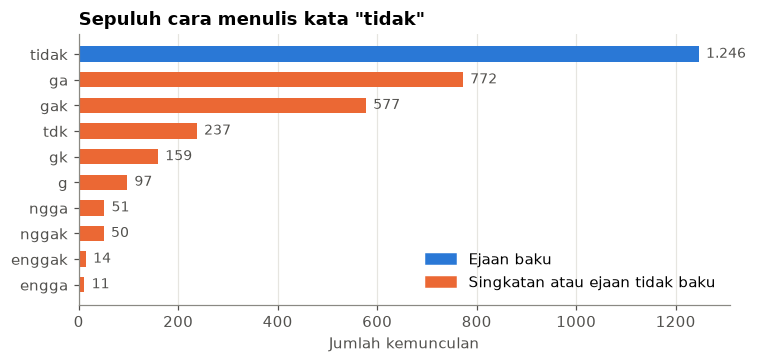

In [16]:
# Berbagai cara menulis kata "tidak"
varian_tidak = ["tidak", "ga", "gak", "tdk", "gk", "g", "ngga", "nggak", "enggak", "engga"]
jumlah_varian = frekuensi.reindex(varian_tidak).fillna(0).astype(int).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(jumlah_varian.index, jumlah_varian.values,
        color=[BIRU if k == "tidak" else ORANYE for k in jumlah_varian.index], height=0.6)
for y, v in enumerate(jumlah_varian.values):
    ax.text(v + 15, y, angka(v), va="center", fontsize=9, color=TEKS)
ax.set_title('Sepuluh cara menulis kata "tidak"')
ax.set_xlabel("Jumlah kemunculan")
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=BIRU, label="Ejaan baku"), Patch(color=ORANYE, label="Singkatan atau ejaan tidak baku")],
          loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

In [17]:
# Beberapa kata lain yang punya banyak bentuk
for kelompok in [
    ["barang", "brg", "brang"],
    ["sudah", "sdh", "udah", "udh", "dah"],
    ["yang", "yg"],
    ["dengan", "dgn", "dg"],
    ["terimakasih", "makasih", "thanks", "thx", "trims", "tq", "mksh"],
]:
    print({k: int(frekuensi.get(k, 0)) for k in kelompok})

{'barang': 15772, 'brg': 638, 'brang': 111}
{'sudah': 5677, 'sdh': 1234, 'udah': 947, 'udh': 328, 'dah': 704}
{'yang': 1469, 'yg': 2268}
{'dengan': 5692, 'dgn': 1259, 'dg': 478}
{'terimakasih': 1607, 'makasih': 1331, 'thanks': 2273, 'thx': 837, 'trims': 496, 'tq': 406, 'mksh': 166}


Catatan:

Bahasa ulasan sangat informal. Ada tiga pola utama:

1. Singkatan. Kata "tidak" muncul dalam 10 ejaan berbeda, dan jumlah bentuk tidak bakunya (ga, gak, tdk, gk, dan lain-lain) lebih banyak daripada "tidak" itu sendiri. "yg" bahkan lebih sering dipakai daripada "yang". Bagi model, "tidak" dan "gak" adalah dua kata yang berbeda, kecuali disamakan dulu di tahap data prep.
2. Campuran bahasa Inggris. Kata seperti "thanks", "good", "fast", dan "recommended" sering muncul.
3. Kata sapaan dan basa-basi, seperti "gan", "seller", "semoga", dan "sukses". Kata-kata ini muncul di hampir semua ulasan, sehingga tidak banyak membantu membedakan ulasan positif dan negatif.

Kata "tidak" dan variannya sangat penting untuk sentimen, karena bisa membalik makna kalimat. Contohnya, "bagus" dan "tidak bagus". Karena itu, kata "tidak" tidak boleh ikut dibuang saat membuang kata-kata umum (stopword) di tahap data prep.

## 8. Karakter khusus dalam teks

In [18]:
print("Mengandung kode HTML (&amp;, &#34;, dll):", angka(df["text"].str.contains(r"&#?\w+;", regex=True).sum()))
print("Mengandung huruf berulang (baguuus)      :", angka((df["text"].str.count(r"([a-zA-Z])\1\1") > 0).sum()))
print("Mengandung titik berulang (...)          :", angka(df["text"].str.contains(r"\.\.\.", regex=True).sum()))
print("Mengandung emoji atau karakter non-ASCII :", angka(df["text"].str.contains(r"[^\x00-\x7F]", regex=True).sum()))

Mengandung kode HTML (&amp;, &#34;, dll): 682
Mengandung huruf berulang (baguuus)      : 3.913
Mengandung titik berulang (...)          : 8.836
Mengandung emoji atau karakter non-ASCII : 1.534


In [19]:
df["text"].str.findall(r"&#?\w+;").explode().value_counts().head()

text
&amp;    541
&#39;    242
&#34;    141
&lt;       3
&gt;       3
Name: count, dtype: int64

In [20]:
with pd.option_context("display.max_colwidth", 100):
    display(df.loc[df["text"].str.contains(r"&#?\w+;", regex=True), "text"].head(5))

49                                                                       brg diterima dg baik&amp; lengkap
50                                                                        Great Product &amp; Great Seller
150                                                        barang jelek copot&#34; terus tmpat taro isinya
174    Pengiriman &amp; packaging bagus. Sesuai foto &amp; deskripsi. Staple gun agak berat ketika dipake.
184                                                                  Produk bekerja dengan baik &amp; kuat
Name: text, dtype: str

Catatan:

- 682 ulasan mengandung kode HTML seperti `&amp;` (tanda &), `&#39;` (tanda petik '), dan `&#34;` (tanda petik "). Kode ini muncul karena teks tersimpan dalam format HTML saat diambil dari situs. Contohnya, "gara&#34;" seharusnya "gara\"" (maksudnya gara-gara). Kode seperti ini perlu dikembalikan ke karakter aslinya sebelum tanda baca dibuang, supaya tidak tersisa potongan kata aneh seperti "amp" atau "quot". Buktinya, "amp" masuk daftar 100 kata paling sering di bagian 7.
- 3.913 ulasan punya huruf yang diulang tiga kali atau lebih, seperti "baguuuus" atau "okkkkk". Huruf berulang perlu diringkas supaya "baguuuus" dan "bagus" dianggap kata yang sama.
- 8.836 ulasan mengandung titik berulang, dan 1.534 ulasan mengandung emoji. Keduanya dibuang saat data prep.

## 9. Rating yang tidak cocok dengan isi ulasan

In [21]:
# Ulasan bintang 1 dan 2 yang berisi kata pujian, tanpa satu pun kata keluhan
teks_kecil = df["text"].str.lower()
ada_pujian = teks_kecil.str.contains(
    r"\b(?:bagus|mantap|mantab|sesuai|puas|recommended|cepat|terima kasih|terimakasih|good|top)\b", regex=True
)
ada_keluhan = teks_kecil.str.contains(
    r"\b(?:tidak|tdk|gak|ga|gk|kecewa|rusak|jelek|kurang|belum|blm|lama|salah|beda|mati|tapi|tp|cacat|kok|parah|buruk|retur)\b",
    regex=True,
)
pujian_saja = df[(df["rating"] <= 2) & ada_pujian & ~ada_keluhan]
print(f"Ulasan bintang 1-2 yang hanya berisi pujian: {len(pujian_saja)} dari {(df['rating'] <= 2).sum()}")

with pd.option_context("display.max_colwidth", 120):
    display(pujian_saja[["rating", "text"]].sample(10, random_state=1))

Ulasan bintang 1-2 yang hanya berisi pujian: 36 dari 925


,rating,text
35779,2,paket udah keterima terimakasih
39140,2,"Barangx sesuai deskripsi, diterima dlm kondisi ok, cuma sayangx baru dipakai sehari sdh robek, kualitas sesuai harga."
34883,2,Di Catatan penjual berat 6 kg dgn harapan net lumayan bagus nyatanya cuma 4kg berarti bahannya tipis jaring ti...
4230,2,"😥😥 not good quality, not even close."
22008,2,"Trims, joystick sudah sampe (pengiriman cepat), seller fast response."
16762,2,"barang sudah sampe,thanks. lumayan bagus"
26055,1,"Yang di kirim ke saya bukan sesuai FA180PM111, tetapi untungnya masi bisa di pake di laptop saya...."
28623,2,"pengiriman cepat, packing bagus, sayang kedetect ama lenovo not genuine. \nsaya lagi apes kali.\ntrims"
35422,2,Fast Respon ! Good job.............................................................
33768,2,yaaa begitulah harga sesuai dengan kwalita barang....


Catatan:

Sebagian ulasan bintang 1 dan 2 isinya justru pujian, misalnya "paket udah keterima terimakasih", "Fast Respon ! Good job...", dan "Trims, joystick sudah sampe (pengiriman cepat), seller fast response." Kemungkinan pembeli salah menekan bintang, atau rating diberikan untuk hal lain yang tidak ditulis di ulasan.

Pencarian kata sederhana di atas menemukan 36 dari 925 ulasan bintang 1 dan 2 (sekitar 4%) yang hanya berisi pujian. Angka ini perkiraan kasar. Sebagian ulasan yang tertangkap sebenarnya tetap keluhan, misalnya "not good quality, not even close" atau "baru dipakai sehari sdh robek", sedangkan ulasan campuran seperti "barang bagus tapi..." tidak ikut terhitung. Jadi label noise memang ada, tetapi jumlahnya kecil.

Artinya rating bukan label yang sempurna. Kalau rating dipakai sebagai label sentimen, sebagian contoh latihan akan "salah label", dan model akan ikut belajar dari kesalahan itu. Hal seperti ini disebut label noise. Memeriksa semua ulasan satu per satu tidak realistis untuk 40 ribu ulasan, jadi masalah ini diterima sebagai keterbatasan dan dicatat saat menilai model. Contohnya, model yang menebak "positif" untuk ulasan bintang 2 "paket udah keterima terimakasih" sebenarnya tidak salah.

## 10. Sebaran ulasan per produk dan toko

In [22]:
per_produk = df.groupby("product_id").size().sort_values(ascending=False)
print("Jumlah produk unik:", angka(df["product_id"].nunique()))
print("Jumlah toko unik  :", angka(df["shop_id"].nunique()))
print(f"5 produk teratas menyumbang {per_produk.head(5).sum() / len(df):.1%} dari semua ulasan")
per_produk.describe()

Jumlah produk unik: 3.664
Jumlah toko unik  : 158
5 produk teratas menyumbang 12.3% dari semua ulasan


count    3664.000000
mean       11.082697
std        49.884196
min         1.000000
25%         1.000000
50%         2.000000
75%         7.000000
max      1312.000000
dtype: float64

Catatan:

Ulasan berasal dari 3.664 produk, tetapi hanya dari 158 toko. Jumlah ulasan per produk sangat timpang: separuh produk hanya punya 1 atau 2 ulasan, sedangkan satu produk (USB hub) punya 1.312 ulasan. Lima produk teratas saja menyumbang 12% dari seluruh ulasan.

Ini perlu diingat saat menarik kesimpulan. Data ini lebih mencerminkan pengalaman pembeli di sekelompok toko tertentu daripada Tokopedia secara keseluruhan.

## Ringkasan masalah yang ditemukan

Daftar ini menjadi rencana kerja untuk tahap data prep dan model.

1. Rating sangat tidak seimbang: 74,6% bintang 5, dan hanya 2,3% bintang 1 atau 2. Model tidak bisa dinilai dengan akurasi saja, dan perlu penanganan khusus untuk kelas negatif yang sedikit.
2. Label sentimen harus dibuat dari rating. Perlu diputuskan bagaimana rating dikelompokkan, dan bagaimana memperlakukan bintang 3.
3. Rating tidak selalu cocok dengan isi teks (label noise). Ini diterima sebagai keterbatasan.
4. Teks mengandung kode HTML (682 ulasan) yang harus dikembalikan ke karakter aslinya sebelum tanda baca dibuang.
5. Banyak singkatan dan ejaan tidak baku. Contohnya, "tidak" punya 10 ejaan. Perlu kamus normalisasi untuk kata-kata yang paling sering.
6. Huruf berulang (3.913 ulasan), titik berulang, dan emoji perlu dibersihkan.
7. Kata "tidak" dan variannya penting untuk sentimen, jadi tidak boleh ikut terbuang sebagai stopword.
8. Sebagian ulasan akan menjadi kosong setelah dibersihkan (misalnya ulasan yang hanya berisi emoji atau titik), dan perlu dibuang.
9. Ada 17 ulasan duplikat (teks sama di produk yang sama) yang perlu dibuang. Teks sama di produk berbeda tetap disimpan.
10. Kolom `Unnamed: 0` tidak berguna dan dibuang. Kolom `sold` tidak dipakai.
11. Ulasan negatif terpusat di kategori handphone (46% dari semua ulasan negatif), dan data berasal dari hanya 158 toko. Kedua hal ini membatasi seberapa umum hasil model bisa diterapkan.